In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [12]:
# Step 2: Load the dataset
data = pd.read_csv("/content/drive/MyDrive/Healthcare/Dataset/cardio_train.csv", sep=';')  # update filename if needed



In [13]:
print(data.columns.tolist())


['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']


In [14]:
print("First 5 rows:\n", data.head())
print("\nDataset Info:\n")
print(data.info())
print("\nMissing Values:\n", data.isnull().sum())

First 5 rows:
    id    age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  \
0   0  18393       2     168    62.0    110     80            1     1      0   
1   1  20228       1     156    85.0    140     90            3     1      0   
2   2  18857       1     165    64.0    130     70            3     1      0   
3   3  17623       2     169    82.0    150    100            1     1      0   
4   4  17474       1     156    56.0    100     60            1     1      0   

   alco  active  cardio  
0     0       1       0  
1     0       1       1  
2     0       0       1  
3     0       1       1  
4     0       0       0  

Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height  

In [15]:
data.drop('id', axis=1, inplace=True)


In [16]:
if 'id' in data.columns:
    data.drop('id', axis=1, inplace=True)


In [17]:
# Step 4: Remove invalid blood pressure values
data = data[data['ap_hi'] > data['ap_lo']]
data = data[(data['ap_hi'] < 250) & (data['ap_lo'] < 200)]

In [18]:
# Step 5: Define features and target
X = data.drop('cardio', axis=1)
y = data['cardio']

In [19]:

# Step 6: Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [20]:

# Step 7: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


In [21]:
# Step 8: Model training
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [22]:
# Step 9: Predictions & evaluation
y_pred = model.predict(X_test)

print("\nModel Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))



Model Accuracy: 0.7130592942888323

Confusion Matrix:
 [[5057 1937]
 [2007 4744]]

Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.72      0.72      6994
           1       0.71      0.70      0.71      6751

    accuracy                           0.71     13745
   macro avg       0.71      0.71      0.71     13745
weighted avg       0.71      0.71      0.71     13745



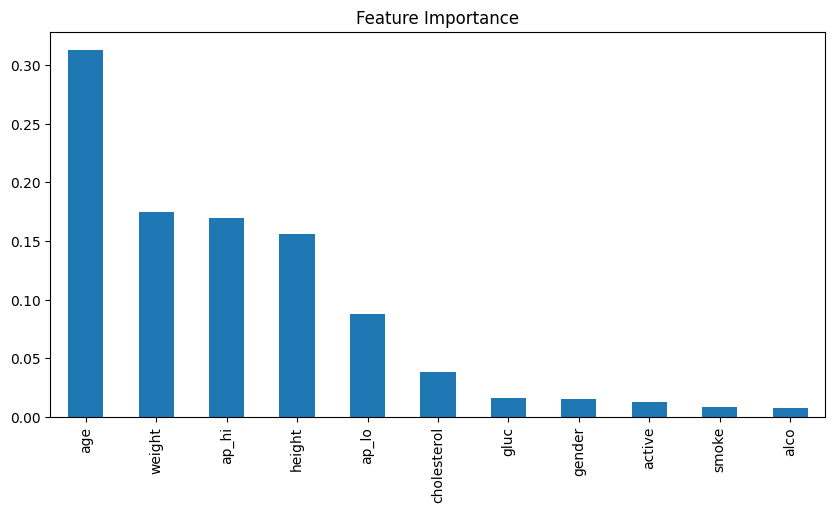

In [23]:

# Step 10: Feature importance
feature_importance = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 5))
feature_importance.plot(kind='bar', title='Feature Importance')
plt.show()

In [26]:
# Save trained model
import pickle
with open("/content/drive/MyDrive/Healthcare/models/cardio_model.pkl", "wb") as model_file:
    pickle.dump(model, model_file)

# Save the scaler (important for later prediction)
with open("/content/drive/MyDrive/Healthcare/models/cardio_scaler.pkl", "wb") as scaler_file:
    pickle.dump(scaler, scaler_file)

print("\n✅ Model and scaler saved successfully as 'cardio_model.pkl' and 'cardio_scaler.pkl'")


✅ Model and scaler saved successfully as 'cardio_model.pkl' and 'cardio_scaler.pkl'
